In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
main = pd.read_csv('maintenance_data.csv')
main

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


In [3]:
main.head()

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1


In [4]:
main.isnull()

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False


In [5]:
main.isnull().sum()

lifetime          0
broken            0
pressureInd       0
moistureInd       0
temperatureInd    0
team              0
provider          0
dtype: int64

In [6]:
main.dtypes

lifetime            int64
broken              int64
pressureInd       float64
moistureInd       float64
temperatureInd    float64
team               object
provider           object
dtype: object

In [7]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   lifetime        1000 non-null   int64  
 1   broken          1000 non-null   int64  
 2   pressureInd     1000 non-null   float64
 3   moistureInd     1000 non-null   float64
 4   temperatureInd  1000 non-null   float64
 5   team            1000 non-null   object 
 6   provider        1000 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 54.8+ KB


In [8]:
for i in main.columns:
    print(i, ':', '\n', main[i].unique(), '\n')

lifetime : 
 [56 81 60 86 34 30 68 65 23 38 29 82 80 48 92 88 74 61 35 26 63 79 53 73
 13 36 31 25 58 19 84 12 15 43  1 20 16  3 18  7 47 39 57  4 24 28 49 76
 52  8 40 46  5 41 93 77 62 85 55 33 17 45  9 72 50 42 44 54 64 27 22 59
 66 83 14 51 71 21 78  6 69 89  2 67 87 11 10 32 37 90] 

broken : 
 [0 1] 

pressureInd : 
 [ 92.17885406  72.07593772  96.27225443  94.40646126  97.75289859
  87.67880097  94.61417404  96.48330289 105.486158    99.17823531
  97.81784409  67.81225145  86.36611059  76.14465414 103.1072633
  88.41407945  84.35504868  79.66925455  86.22910861  84.17942039
 100.0059233  115.6075596   97.69718903 101.4156229  118.9786971
 102.1127749  129.1243378  109.0330362  107.2980695  127.2639544
 138.1911205   72.55408417  95.21464918  91.24713174  81.55537698
  69.13459519 132.8574784   54.73533145  84.89864628  94.15228726
  84.34406647  95.75352436 123.9284399  101.5053508  120.9455502
  83.06857115 113.3491219   75.64669299 113.4358321   81.77978353
  68.85065142 150.6

In [9]:
d = main.describe(include='all')
d

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,NaN,NaN,NaN,3,4
top,NaN,NaN,NaN,NaN,NaN,TeamB,Provider2
freq,NaN,NaN,NaN,NaN,NaN,356,266
mean,55.195000,0.397000,98.599338,99.376723,100.628541,NaN,NaN
std,26.472737,0.489521,19.964052,9.988726,19.633060,NaN,NaN
min,1.000000,0.000000,33.481917,58.547301,42.279598,NaN,NaN
25%,34.000000,0.000000,85.558076,92.771764,87.676913,NaN,NaN
50%,60.000000,0.000000,97.216997,99.433959,100.592277,NaN,NaN
75%,80.000000,1.000000,112.253190,106.120762,113.662885,NaN,NaN


In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [11]:
main.team = le.fit_transform(main.team)

In [12]:
main.team.unique()

array([0, 2, 1])

In [13]:
le.inverse_transform([0,2,1])

array(['TeamA', 'TeamC', 'TeamB'], dtype=object)

In [14]:
main.provider = le.fit_transform(main.provider)
main.provider.unique()

array([3, 0, 1, 2])

In [15]:
le.inverse_transform([3,0,1,2])

array(['Provider4', 'Provider1', 'Provider2', 'Provider3'], dtype=object)

In [16]:
main.head()

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,0,3
1,81,1,72.075938,103.065701,87.271062,2,3
2,60,0,96.272254,77.801376,112.196170,0,0
3,86,1,94.406461,108.493608,72.025374,2,1
4,34,0,97.752899,99.413492,103.756271,1,0


In [17]:
c = main.corr()
c

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
lifetime,1.000000,0.702656,0.000943,0.001196,0.001744,-0.046537,-0.025172
broken,0.702656,1.000000,-0.028942,-0.019520,0.015364,0.030876,-0.062972
pressureInd,0.000943,-0.028942,1.000000,0.020543,0.003641,-0.069528,-0.004337
moistureInd,0.001196,-0.019520,0.020543,1.000000,-0.009842,0.022420,0.028906
temperatureInd,0.001744,0.015364,0.003641,-0.009842,1.000000,0.007310,-0.010822
team,-0.046537,0.030876,-0.069528,0.022420,0.007310,1.000000,0.005606
provider,-0.025172,-0.062972,-0.004337,0.028906,-0.010822,0.005606,1.000000


In [18]:
ip = main.drop('broken', axis=1)
op = main.broken

In [19]:
ip

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
0,56,92.178854,104.230204,96.517159,0,3
1,81,72.075938,103.065701,87.271062,2,3
2,60,96.272254,77.801376,112.196170,0,0
3,86,94.406461,108.493608,72.025374,2,1
4,34,97.752899,99.413492,103.756271,1,0
...,...,...,...,...,...,...
995,88,88.589759,112.167556,99.861456,1,3
996,88,116.727075,110.871332,95.075631,0,3
997,22,104.026778,88.212873,83.221220,1,0
998,78,104.911649,104.257296,83.421491,0,3


In [20]:
op

0      0
1      1
2      0
3      1
4      0
      ..
995    1
996    1
997    0
998    0
999    0
Name: broken, Length: 1000, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ip, op, test_size=0.2, random_state=3000)

In [22]:
x_train

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
16,48,84.355049,103.174919,102.399715,2,2
846,60,88.468744,104.743459,86.834473,2,2
10,38,97.817844,111.074168,94.942443,1,3
379,65,105.410322,81.933036,110.817436,0,2
305,30,101.352639,98.469451,73.084210,0,3
...,...,...,...,...,...,...
949,74,110.197671,109.912879,96.717913,2,0
942,66,71.921834,106.890108,66.868012,1,2
769,45,113.516983,76.999898,77.194014,1,1
563,40,101.632660,82.841519,97.313544,1,1


In [23]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(800, 6)
(800,)
(200, 6)
(200,)


In [24]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)

In [25]:
x_train

array([[-0.25499869, -0.72230593,  0.39397997,  0.08410908,  1.28878721,
         0.50182605],
       [ 0.19450322, -0.51513376,  0.5495662 , -0.70707115,  1.28878721,
         0.50182605],
       [-0.62958361, -0.04429839,  1.17752033, -0.29494355,  0.03905416,
         1.40196246],
       ...,
       [-0.36737416,  0.74633494, -2.20236632, -1.19709502,  0.03905416,
        -0.39831036],
       [-0.55466663,  0.14782175, -1.62292563, -0.17442067,  0.03905416,
        -0.39831036],
       [-0.10516472, -0.28190593,  0.42287175, -1.48663442,  0.03905416,
         0.50182605]])

In [26]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
x_train = mm.fit_transform(x_train)
x_test  = mm.transform(x_test)

In [27]:
x_train

array([[0.51086957, 0.35334367, 0.63710292, 0.46152327, 1.        ,
        0.66666667],
       [0.64130435, 0.38325734, 0.65949536, 0.34203379, 1.        ,
        0.66666667],
       [0.40217391, 0.45124143, 0.74987242, 0.40427613, 0.5       ,
        1.        ],
       ...,
       [0.47826087, 0.56540126, 0.26342888, 0.26802701, 0.5       ,
        0.33333333],
       [0.42391304, 0.47898172, 0.34682374, 0.42247833, 0.5       ,
        0.33333333],
       [0.55434783, 0.41693319, 0.64126111, 0.22429878, 0.5       ,
        0.66666667]])

In [28]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [29]:
pred = lr.predict(x_test)
pred

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1], dtype=int64)

In [30]:
y_test

73     0
924    0
572    0
837    0
707    0
      ..
781    0
174    1
46     0
76     1
840    1
Name: broken, Length: 200, dtype: int64

In [31]:
 from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, pred)

In [32]:
r2 = r2_score(y_test, pred)

In [33]:
print("MSE: ", mse)
print("R2 Score: ", r2)

MSE:  0.23
R2 Score:  0.0665584415584417


In [34]:
df = pd.DataFrame({'Y_test': list(y_test), 'Prediction': pred})
df

,Y_test,Prediction
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
195,0,0
196,1,0
197,0,0
198,1,1


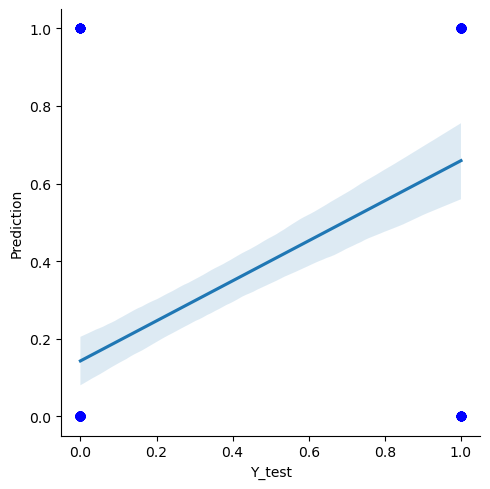

In [35]:
sns.lmplot(x="Y_test", y="Prediction", data=df, scatter_kws={"color": "blue"})
plt.show()

### Logistic Regression = 1 / e^-x

In [36]:
main2 = pd.read_csv('maintenance_data.csv')
main2

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

### Confusion Matrix

#### It is used to check performance of the Classification model.

#### Accuracy - It is defind as the ratio between (correct prediction / All the predictions) : tp+tn /  tp + fn + fp + tn
#### Recall - It is defind as the ratio between prediction that is actually positive devided by all the actual YES cases : tp / tp + fn
#### Precision - It is defind as prediction that is actually positive devided by predicted YES cases : tp / tp + fp
#### F1 Score - (Precision^-1 + Recall^-1 / 2 )^-1 OR (2 * Recall * Precission) / (Recall + precision)

## Accruracy

In [38]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(y_test, pred)
re = recall_score(y_test, pred)
pr = precision_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("Accuracy: ", ac)
print("Recall: ", re)
print("Precision: ", pr)
print("F1 Score: ", f1)

Accuracy:  0.77
Recall:  0.6590909090909091
Precision:  0.7837837837837838
F1 Score:  0.7160493827160493


In [39]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(pred, y_test)
cm

array([[96, 30],
       [16, 58]], dtype=int64)

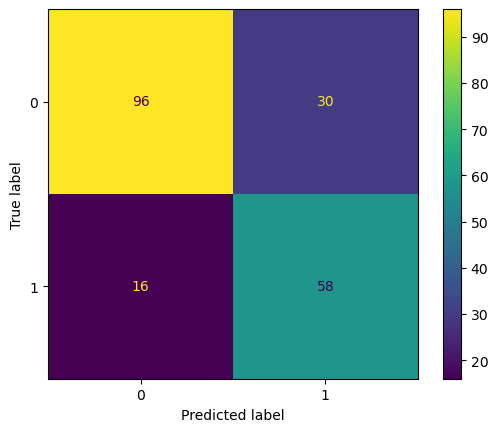

In [40]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [41]:
df = pd.DataFrame({'y_test':list(y_test), 'Prediction': pred})
df

,y_test,Prediction
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
195,0,0
196,1,0
197,0,0
198,1,1


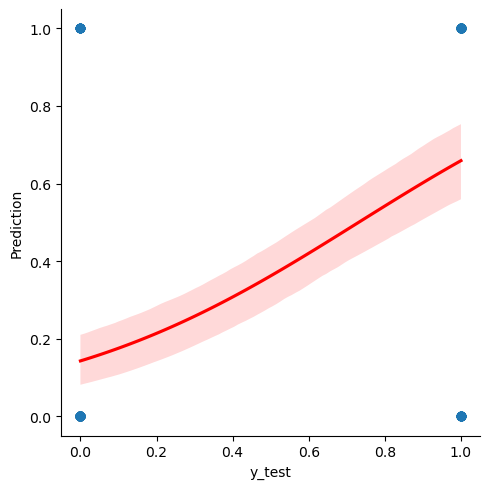

In [42]:
sns.lmplot(x='y_test', y='Prediction', data=df, logistic=True, line_kws={'color':'r'})
plt.show()

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [44]:
pred1 = knn.predict(x_test)
pred1

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1], dtype=int64)

In [45]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
ac = accuracy_score(y_test, pred1)
re = recall_score(y_test, pred1)
pr = precision_score(y_test, pred1)
f1 = f1_score(y_test, pred1)

In [46]:
print("Accuracy: ", ac)
print("Recall: ", re)
print("Precision: ", pr)
print("F1 Score: ", f1)

Accuracy:  0.855
Recall:  0.8977272727272727
Precision:  0.797979797979798
F1 Score:  0.8449197860962567


In [47]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)

GaussianNB()

In [48]:
pred2 = gnb.predict(x_test)
pred2

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1], dtype=int64)

In [49]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
ac = accuracy_score(y_test, pred2)
re = recall_score(y_test, pred2)
pr = precision_score(y_test, pred2)
f1 = f1_score(y_test, pred2)

In [50]:
print("Accuracy: ", ac)
print("Recall: ", re)
print("Precision: ", pr)
print("F1 Score: ", f1)

Accuracy:  0.835
Recall:  0.8068181818181818
Precision:  0.8160919540229885
F1 Score:  0.8114285714285714


In [51]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, pred2)
cm

array([[96, 16],
       [17, 71]], dtype=int64)

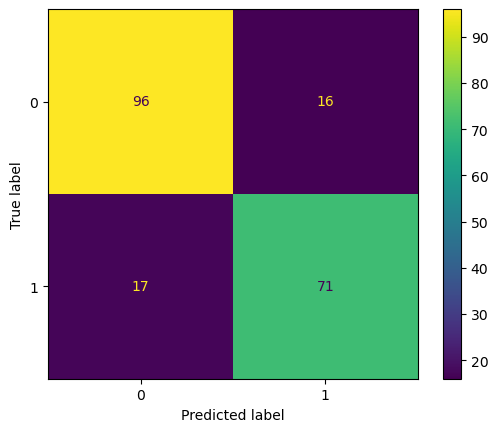

In [52]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

# SVM - Support Vector Machine

# The goal of the svm is to create best line or decision boundary to segregate data into different classes so that we can put new data to the correct class or category.

In [54]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', gamma=0.03, C=1000)
svc.fit(x_train, y_train)

SVC(C=1000, gamma=0.03)

In [55]:
pred3 = svc.predict(x_test)
pred3

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1], dtype=int64)

In [56]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
ac = accuracy_score(y_test, pred3)
re = recall_score(y_test, pred3)
pr = precision_score(y_test, pred3)
f1 = f1_score(y_test, pred3)

In [57]:
print("Accuracy: ", ac)
print("Recall: ", re)
print("Precision: ", pr)
print("F1 Score: ", f1)

Accuracy:  0.925
Recall:  1.0
Precision:  0.8543689320388349
F1 Score:  0.9214659685863874


In [58]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, pred2)
cm

array([[96, 16],
       [17, 71]], dtype=int64)

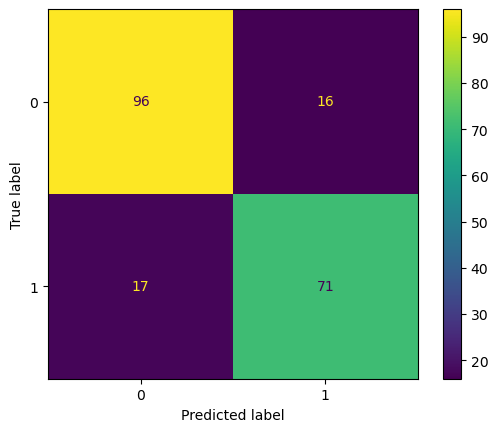

In [59]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [60]:
df = pd.DataFrame({'y_test':list(y_test), 'Prediction': pred3})
df

,y_test,Prediction
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
195,0,0
196,1,1
197,0,0
198,1,1


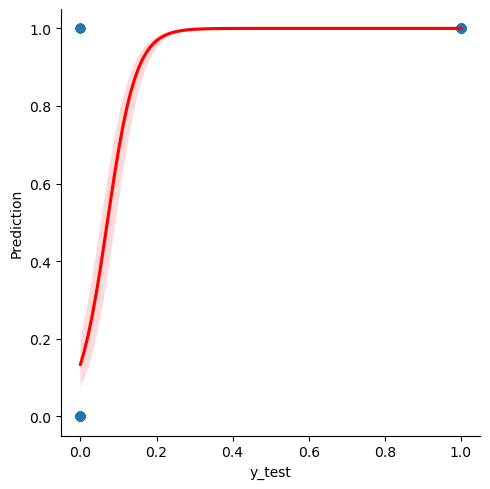

In [61]:
sns.lmplot(x='y_test', y='Prediction', data=df, logistic=True, line_kws={'color':'r'})
plt.show()